# 1. Importación de librerías

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os
import seaborn as sns

# 2. Carga del dataset

In [3]:
df_full = pd.read_csv('../data/processed/coffee_data_cleaned_final.csv')

# 3. Análisis de Codo y Silueta para la Especie Arábica

Análisis para especie: ARABICA
Muestras de Arabica: 1304
Muestras de Robusta reservadas: 28


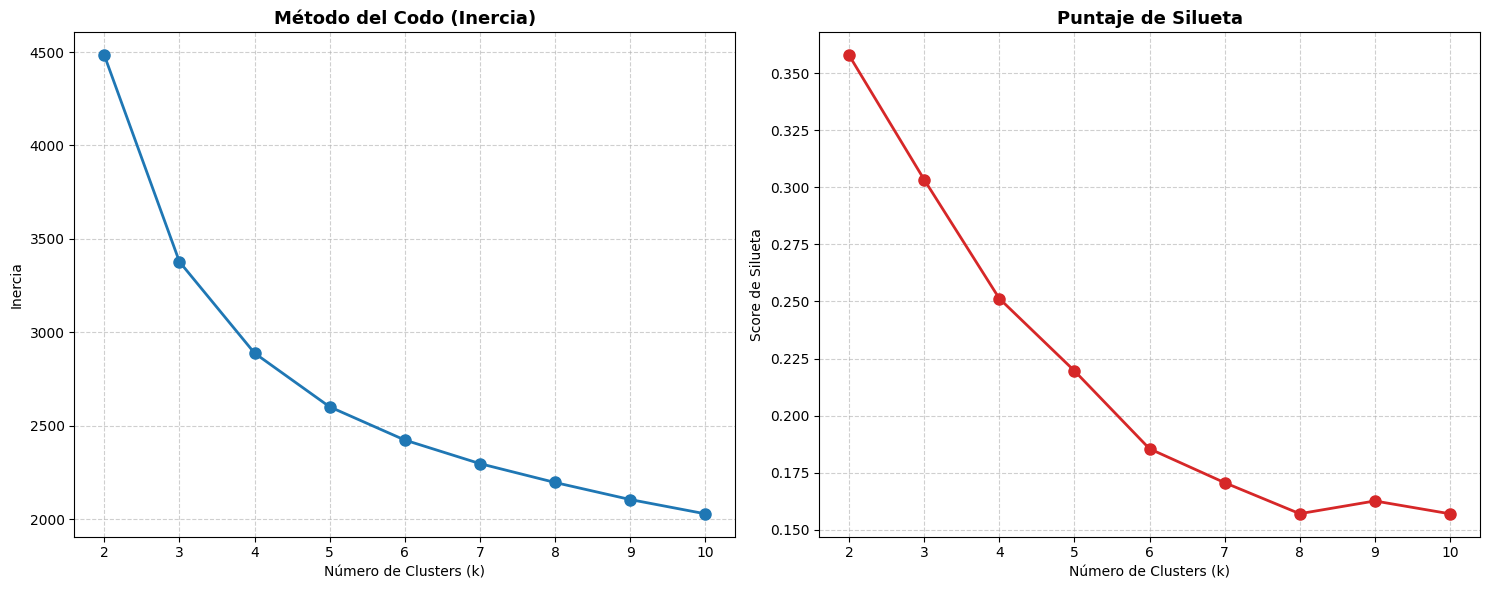

In [ ]:
try:
    base_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
    path_recommender = os.path.join(base_path, "models", "recommender")
    
    if not os.path.exists(path_recommender):
        os.makedirs(path_recommender)
        print(f"Carpeta creada: {path_recommender}")

    df = df_full[df_full['Species'] == 'Arabica'].copy()
    robusta_count = len(df_full[df_full['Species'] == 'Robusta'])
    
    print(f"Análisis para especie: ARABICA")
    print(f"Muestras de Arabica: {df.shape[0]}")
    print(f"Muestras de Robusta reservadas: {robusta_count}")

    features_sabor = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance']
    X = df[features_sabor]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    inercia = []
    siluetas = []
    rango_k = range(2, 11)

    for k in rango_k:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        
        inercia.append(kmeans.inertia_)
        siluetas.append(silhouette_score(X_scaled, labels))

    df_metrics_clusters = pd.DataFrame({
        'k_clusters': list(rango_k),
        'inercia_codo': inercia,
        'puntaje_silueta': siluetas
    })
    
    path_csv_clusters = os.path.join(path_recommender, "metricas_optimizacion_clusters.csv")
    df_metrics_clusters.to_csv(path_csv_clusters, index=False)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    ax1.plot(rango_k, inercia, 'o-', color='#1f77b4', linewidth=2, markersize=8)
    ax1.set_title('Método del Codo (Inercia)', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Número de Clusters (k)')
    ax1.set_ylabel('Inercia')
    ax1.grid(True, linestyle='--', alpha=0.6)

    ax2.plot(rango_k, siluetas, 'o-', color='#d62728', linewidth=2, markersize=8)
    ax2.set_title('Puntaje de Silueta', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Número de Clusters (k)')
    ax2.set_ylabel('Score de Silueta')
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ Error durante la ejecución: {e}")

# 4.Aplicación de K-Means (k=3) en Arábica y Categorización de Robusta

In [9]:
try:
    base_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
    path_recommender = os.path.join(base_path, "models", "recommender")
    
    if not os.path.exists(path_recommender):
        os.makedirs(path_recommender)

    df_arabica = df_full[df_full['Species'] == 'Arabica'].copy()
    df_robusta = df_full[df_full['Species'] == 'Robusta'].copy()
    
    features_sabor = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance']
    
    scaler = StandardScaler()
    X_arabica_scaled = scaler.fit_transform(df_arabica[features_sabor])

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_arabica['Cluster'] = kmeans.fit_predict(X_arabica_scaled)

    df_robusta['Cluster'] = 3

    df_final = pd.concat([df_arabica, df_robusta]).reset_index(drop=True)

    resumen = df_final.groupby('Cluster')[features_sabor].mean()
    
    conteos = df_final['Cluster'].value_counts().sort_index().to_frame(name='Cantidad')

    path_resumen = os.path.join(path_recommender, "perfil_sabor_clusters.csv")
    resumen.to_csv(path_resumen)

    path_data_final = os.path.join(path_recommender, "coffee_catalog_clustered.csv")
    df_final.to_csv(path_data_final, index=False)

    print("--- RESUMEN DE PERFILES (PROMEDIOS) ---")
    print(resumen)
    print("\n--- CANTIDAD DE CAFÉS POR GRUPO ---")
    print(conteos)

except Exception as e:
    print(f"❌ Error: {e}")

--- RESUMEN DE PERFILES (PROMEDIOS) ---
            Aroma    Flavor  Aftertaste   Acidity      Body   Balance
Cluster                                                              
0        7.883725  7.894771    7.785131  7.895588  7.830327  7.893954
1        7.576199  7.543660    7.421872  7.528851  7.516553  7.540270
2        7.230410  7.091945    6.962901  7.192628  7.222389  7.097884
3        7.702500  7.630714    7.559643  7.657143  7.506786  7.541786

--- CANTIDAD DE CAFÉS POR GRUPO ---
         Cantidad
Cluster          
0             306
1             705
2             293
3              28


# 5.Mapa Bidimensional de Perfiles Sensoriales (Arábica)

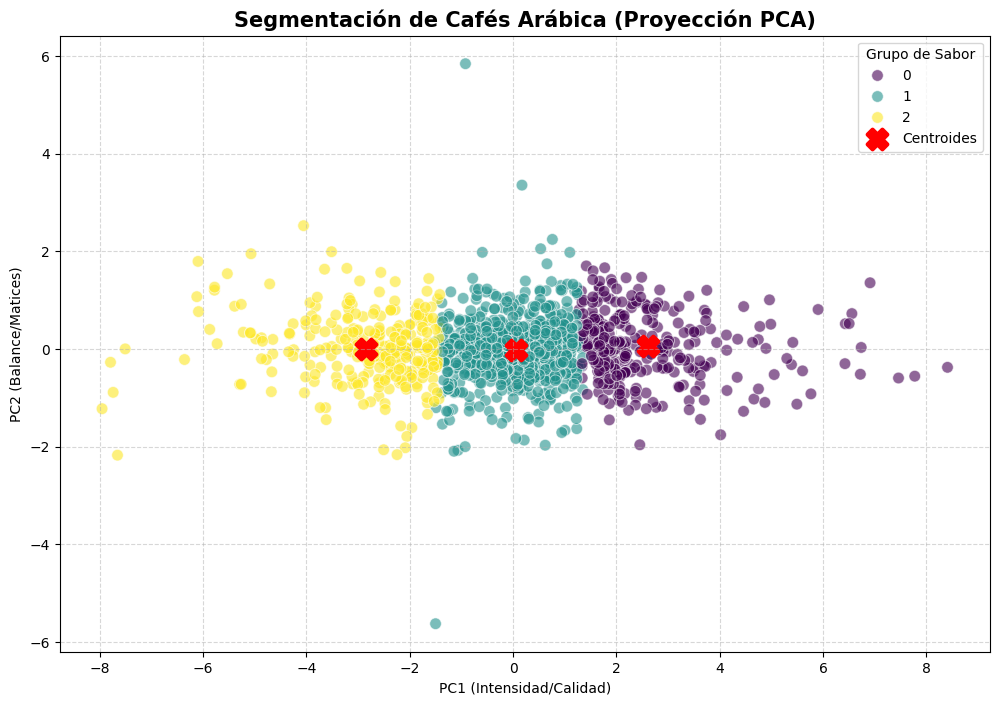

El gráfico explica el 81.81% de la varianza total de los datos.


In [ ]:
try:
    base_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
    path_recommender = os.path.join(base_path, "models", "recommender")
    
    if not os.path.exists(path_recommender):
        os.makedirs(path_recommender)

    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(X_scaled)

    # Creamos el DataFrame con los resultados del PCA
    df_plot = pd.DataFrame(
        data=pca_data, 
        columns=['PC1 (Intensidad/Calidad)', 'PC2 (Balance/Matices)']
    )
    df_plot['Cluster'] = df_arabica['Cluster'].values

    path_pca_csv = os.path.join(path_recommender, "proyeccion_2d_pca.csv")
    df_plot.to_csv(path_pca_csv, index=False)

    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x='PC1 (Intensidad/Calidad)', 
        y='PC2 (Balance/Matices)', 
        hue='Cluster', 
        data=df_plot, 
        palette='viridis', 
        s=70, 
        alpha=0.6,
        edgecolor='w'
    )

    centroids_scaled = kmeans.cluster_centers_
    centroids_pca = pca.transform(centroids_scaled)
    plt.scatter(
        centroids_pca[:, 0], centroids_pca[:, 1], 
        marker='X', s=200, linewidths=3, color='red', label='Centroides'
    )
    
    plt.title('Segmentación de Cafés Arábica (Proyección PCA)', fontsize=15, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title='Grupo de Sabor')
    plt.show()

except Exception as e:
    print(f"❌ Error: {e}")

print(f"El gráfico explica el {pca.explained_variance_ratio_.sum()*100:.2f}% de la varianza total de los datos.")